In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [35]:
df=pd.read_csv('climate-change.csv')
df

,Country Name,Country Code,Year,average_value_Access to electricity (% of population),average_value_Agricultural land (% of land area),average_value_Agricultural land (sq. km),"average_value_Agriculture, forestry, and fishing, value added (% of GDP)","average_value_Annual freshwater withdrawals, total (% of internal resources)","average_value_Annual freshwater withdrawals, total (billion cubic meters)",average_value_Arable land (% of land area),...,"average_value_School enrollment, primary and secondary (gross), gender parity index (GPI)",average_value_Terrestrial and marine protected areas (% of total territorial area),average_value_Terrestrial protected areas (% of total land area),average_value_Total greenhouse gas emissions (kt of CO2 equivalent),average_value_Urban land area where elevation is below 5 meters (% of total land area),average_value_Urban land area where elevation is below 5 meters (sq. km),average_value_Urban population,average_value_Urban population (% of total population),average_value_Urban population growth (annual %),average_value_Urban population living in areas where elevation is below 5 meters (% of total population)
0,Africa Eastern and Southern,AFE,1987,NaN,44.513309,5428670.0,15.468203,NaN,NaN,5.748789,...,NaN,NaN,NaN,1.928434e+06,NaN,NaN,65511328.0,23.465243,5.030075,NaN
1,Albania,ALB,1977,NaN,40.474453,11090.0,NaN,NaN,NaN,21.167883,...,NaN,NaN,NaN,8.948981e+03,NaN,NaN,832109.0,33.105000,2.810025,NaN
2,Albania,ALB,2019,100.000000,NaN,NaN,18.463380,NaN,NaN,NaN,...,1.01863,NaN,NaN,NaN,NaN,NaN,1747593.0,61.229000,1.071414,NaN
3,Armenia,ARM,2020,NaN,NaN,NaN,11.717313,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1876112.0,63.313000,0.334548,NaN
4,Azerbaijan,AZE,2013,100.000000,57.704545,47698.0,5.366264,NaN,NaN,23.292080,...,NaN,NaN,NaN,8.303000e+04,NaN,NaN,5098727.0,54.145000,1.778515,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16160,Uzbekistan,UZB,1978,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,7.904405e+04,NaN,NaN,6103597.0,40.536000,3.987221,NaN
16161,Vanuatu,VUT,1976,NaN,10.336341,1260.0,NaN,NaN,NaN,1.312551,...,0.89463,NaN,NaN,3.070140e+02,NaN,NaN,14028.0,13.619000,4.751852,NaN
16162,"Yemen, Rep.",YEM,1963,NaN,44.244938,233600.0,NaN,NaN,NaN,2.433850,...,NaN,NaN,NaN,NaN,NaN,NaN,567679.0,10.216000,5.348011,NaN
16163,South Africa,ZAF,1969,NaN,78.963638,957900.0,7.817454,NaN,NaN,10.164126,...,NaN,NaN,NaN,NaN,NaN,NaN,10254488.0,47.704000,2.849924,NaN


In [36]:
af=df.groupby('Country Name')['Year'].count()
af

Country Name
Afghanistan                    61
Africa Eastern and Southern    61
Africa Western and Central     61
Albania                        61
Algeria                        61
                               ..
West Bank and Gaza             61
World                          61
Yemen, Rep.                    61
Zambia                         61
Zimbabwe                       61
Name: Year, Length: 265, dtype: int64

In [37]:
print(df.columns)

Index(['Country Name', 'Country Code', 'Year',
       'average_value_Access to electricity (% of population)',
       'average_value_Agricultural land (% of land area)',
       'average_value_Agricultural land (sq. km)',
       'average_value_Agriculture, forestry, and fishing, value added (% of GDP)',
       'average_value_Annual freshwater withdrawals, total (% of internal resources)',
       'average_value_Annual freshwater withdrawals, total (billion cubic meters)',
       'average_value_Arable land (% of land area)',
       'average_value_CO2 emissions (kg per 2010 US$ of GDP)',
       'average_value_CO2 emissions (kg per 2017 PPP $ of GDP)',
       'average_value_CO2 emissions (kt)',
       'average_value_CO2 emissions (metric tons per capita)',
       'average_value_CO2 emissions from gaseous fuel consumption (% of total)',
       'average_value_CO2 emissions from gaseous fuel consumption (kt)',
       'average_value_CO2 emissions from liquid fuel consumption (% of total)',
    

In [38]:
af = df.groupby(['Country Name','Year'])['average_value_CO2 emissions from liquid fuel consumption (kt)'].mean()
af

Country Name  Year
Afghanistan   1960     271.358
              1961     293.360
              1962     363.033
              1963     392.369
              1964     476.710
                        ...   
Zimbabwe      2016    3164.621
              2017         NaN
              2018         NaN
              2019         NaN
              2020         NaN
Name: average_value_CO2 emissions from liquid fuel consumption (kt), Length: 16165, dtype: float64

In [39]:
zim_af = af.loc['Zimbabwe']
zim_af

Year
1960         NaN
1961         NaN
1962         NaN
1963         NaN
1964    1158.772
          ...   
2016    3164.621
2017         NaN
2018         NaN
2019         NaN
2020         NaN
Name: average_value_CO2 emissions from liquid fuel consumption (kt), Length: 61, dtype: float64

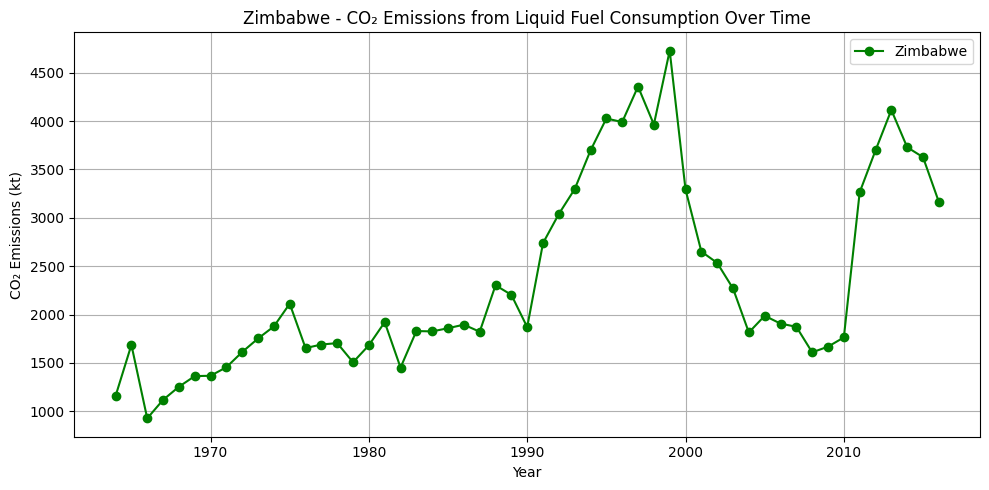

In [40]:
# not deceptive
# Propistion: CO2 emissions in Zimbabwe have drastically increased over time 
plt.figure(figsize=(10, 5))
plt.plot(
    zim_af.index,  # Years
    zim_af.values,  # Emissions
    marker='o',
    linestyle='-',
    color='green',
    label='Zimbabwe'
)

plt.title('Zimbabwe - CO₂ Emissions from Liquid Fuel Consumption Over Time')
plt.xlabel('Year')
plt.ylabel('CO₂ Emissions (kt)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

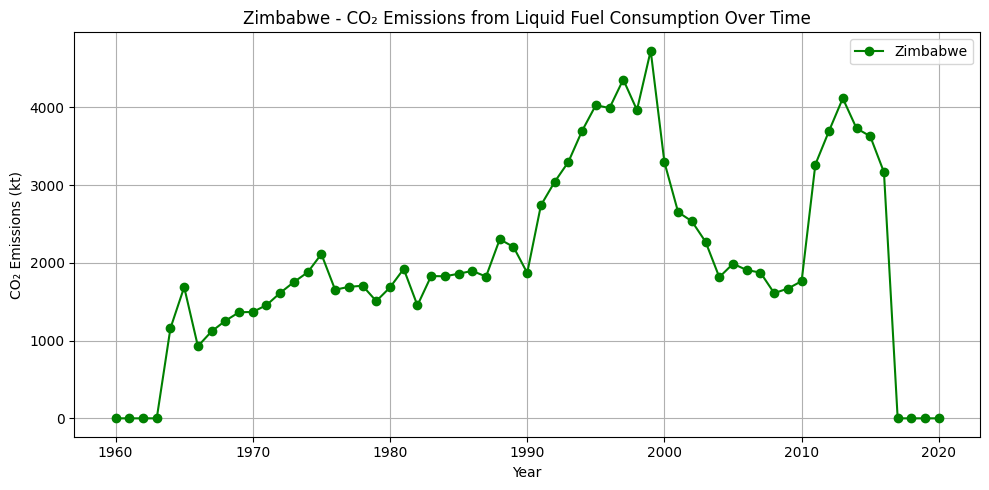

In [41]:
# deceptive
zim_af=zim_af.fillna(0)
plt.figure(figsize=(10, 5))
plt.plot(
    zim_af.index,  # Years
    zim_af.values,  # Emissions
    marker='o',
    linestyle='-',
    color='green',
    label='Zimbabwe'
)

plt.title('Zimbabwe - CO₂ Emissions from Liquid Fuel Consumption Over Time')
plt.xlabel('Year')
plt.ylabel('CO₂ Emissions (kt)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [42]:
bf = df.groupby(['Country Name','Year'])['average_value_Forest area (sq. km)'].mean()
bf

Country Name  Year
Afghanistan   1960         NaN
              1961         NaN
              1962         NaN
              1963         NaN
              1964         NaN
                        ...   
Zimbabwe      2016    176288.6
              2017    175827.9
              2018    175367.2
              2019    174906.5
              2020    174445.8
Name: average_value_Forest area (sq. km), Length: 16165, dtype: float64

In [43]:
af_bf = bf.loc['Afghanistan']
af_bf

Year
1960        NaN
1961        NaN
1962        NaN
1963        NaN
1964        NaN
         ...   
2016    12084.4
2017    12084.4
2018    12084.4
2019    12084.4
2020    12084.4
Name: average_value_Forest area (sq. km), Length: 61, dtype: float64

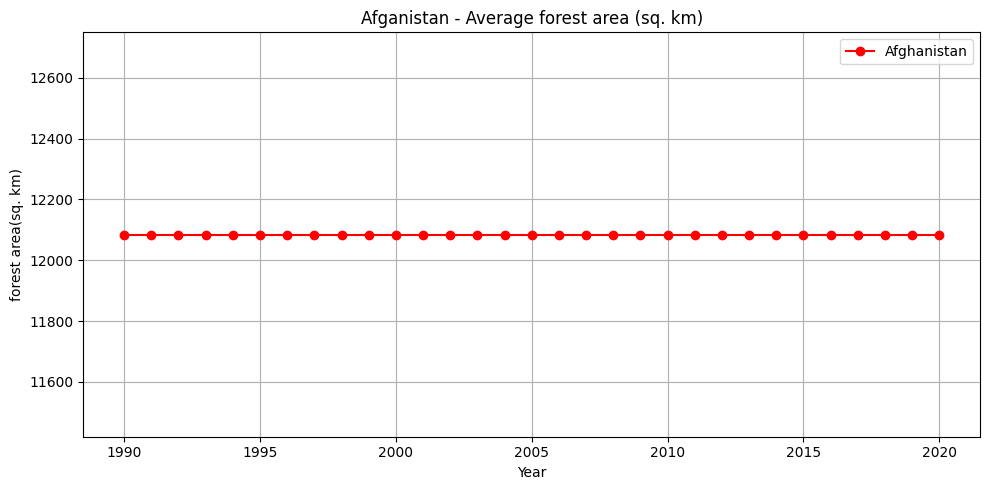

In [44]:
# not deceptive
# The Amount of land in Afghanistan has stayed relatively the same over the years 
plt.figure(figsize=(10, 5))
plt.plot(
    af_bf.index,  # Years
    af_bf.values,  # Emissions
    marker='o',
    linestyle='-',
    color='red',
    label='Afghanistan'
)

plt.title('Afganistan - Average forest area (sq. km)')
plt.xlabel('Year')
plt.ylabel('forest area(sq. km)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [45]:
af_bf=af_bf.fillna(0)
af_bf

Year
1960        0.0
1961        0.0
1962        0.0
1963        0.0
1964        0.0
         ...   
2016    12084.4
2017    12084.4
2018    12084.4
2019    12084.4
2020    12084.4
Name: average_value_Forest area (sq. km), Length: 61, dtype: float64

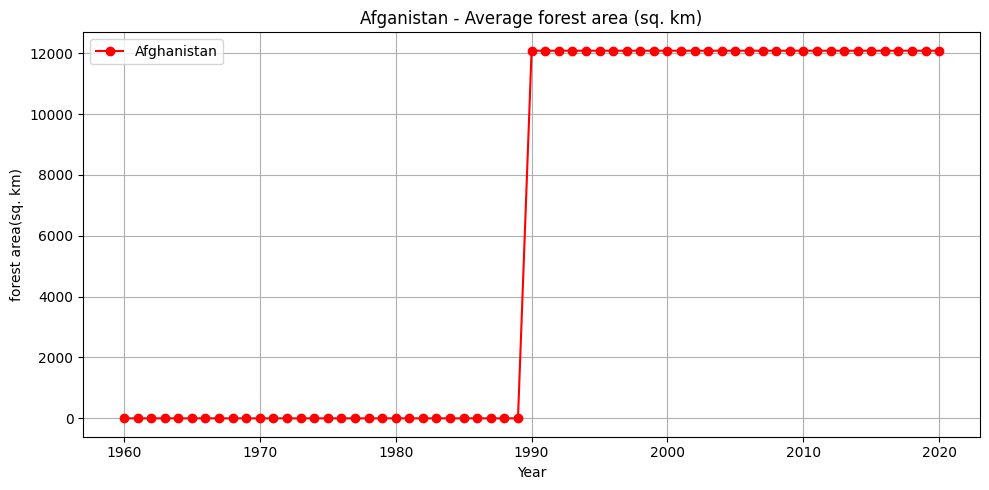

In [46]:
#deceptive
plt.figure(figsize=(10, 5))
plt.plot(
    af_bf.index,  # Years
    af_bf.values,  # Emissions
    marker='o',
    linestyle='-',
    color='red',
    label='Afghanistan'
)

plt.title('Afganistan - Average forest area (sq. km)')
plt.xlabel('Year')
plt.ylabel('forest area(sq. km)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [47]:
us_allies = [
    "United States",
    "United Kingdom",
    "Canada",
    "France",
    "Germany",
    "Italy",
    "Japan",
    "Australia",
    "South Korea",  # Not in your list as-is; will use "Korea, Rep."
    "Korea, Rep.",
    "Israel",
    "Philippines",
    "Thailand",
    "New Zealand",
    "Norway",
    "Denmark",
    "Netherlands",
    "Belgium",
    "Spain",
    "Portugal",
    "Greece",
    "Iceland",
    "Poland",
    "Czech Republic",
    "Hungary",
    "Romania",
    "Slovak Republic",
    "Bulgaria",
    "Estonia",
    "Latvia",
    "Lithuania",
    "Finland",
    "Sweden",
    "Ukraine",
    "Georgia",
    "Singapore",
    "Saudi Arabia",
    "Kuwait",
    "Bahrain",
    "Qatar",
    "United Arab Emirates",
    "Jordan",
    "Egypt, Arab Rep.",
    "Pakistan",
    "Mexico",
    "Colombia",
    "Brazil"
]

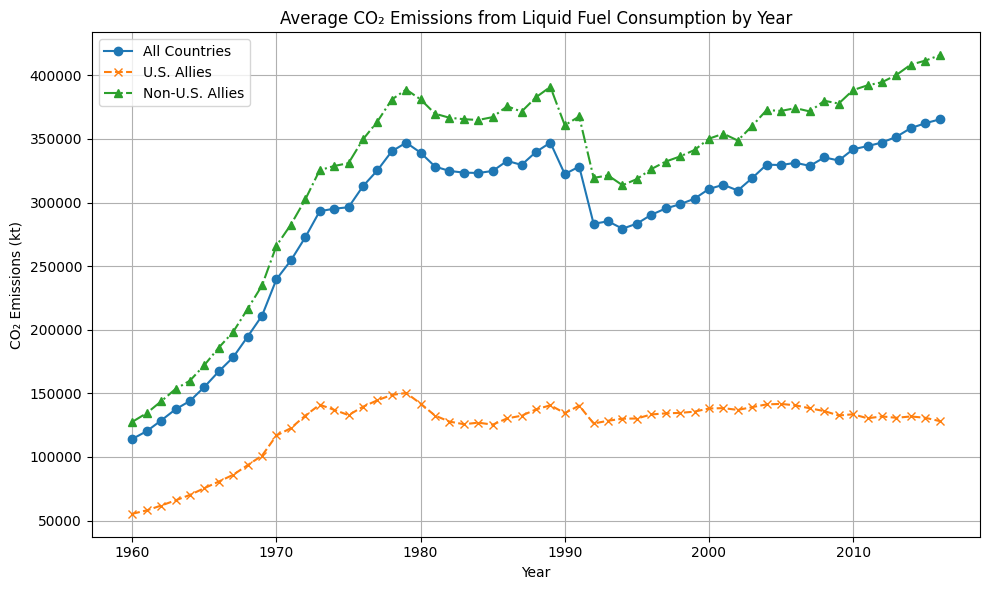

In [50]:
df['USA ally'] = df['Country Name'].isin(us_allies)

# Calculate the average CO2 emissions for all countries
cf_all = df.groupby('Year')['average_value_CO2 emissions from liquid fuel consumption (kt)'].mean()

# Calculate the average CO2 emissions for U.S. allies
cf_allies = df[df['USA ally']].groupby('Year')['average_value_CO2 emissions from liquid fuel consumption (kt)'].mean()

# Calculate the average CO2 emissions for non-U.S. allies
cf_non_allies = df[~df['USA ally']].groupby('Year')['average_value_CO2 emissions from liquid fuel consumption (kt)'].mean()

# Plotting all three on the same graph
plt.figure(figsize=(10, 6))
cf_all.plot(kind='line', marker='o', label='All Countries')
cf_allies.plot(kind='line', marker='x', label='U.S. Allies', linestyle='--')
cf_non_allies.plot(kind='line', marker='^', label='Non-U.S. Allies', linestyle='-.')

# Adding labels and title
plt.title('Average CO₂ Emissions from Liquid Fuel Consumption by Year')
plt.xlabel('Year')
plt.ylabel('CO₂ Emissions (kt)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [51]:
developed_countries = [
    "United States", "Canada", "Germany", "Sweden", "Iceland", "Japan", "Greece", "Australia",
    "Norway", "Finland", "Denmark", "Netherlands", "Switzerland", "United Kingdom", "Ireland",
    "France", "Belgium", "Austria", "New Zealand", "Korea, Rep.", "Italy", "Spain", "Portugal",
    "Israel", "Luxembourg", "Monaco", "Liechtenstein", "United Arab Emirates", "Singapore"
]

# Create the new column 'Development Status'
df['Development Status'] = df['Country Name'].apply(
    lambda x: 'Developed' if x in developed_countries else 'Non-Developed'
)

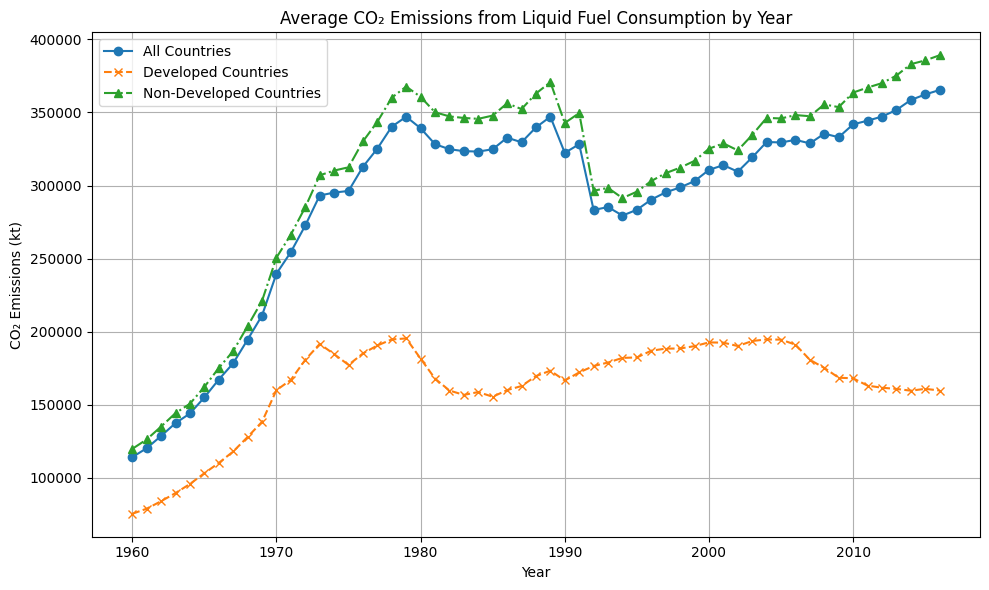

In [52]:
cf_all = df.groupby('Year')['average_value_CO2 emissions from liquid fuel consumption (kt)'].mean()

# Calculate the average CO2 emissions for Developed countries
cf_developed = df[df['Development Status'] == 'Developed'].groupby('Year')['average_value_CO2 emissions from liquid fuel consumption (kt)'].mean()

# Calculate the average CO2 emissions for Non-Developed countries
cf_non_developed = df[df['Development Status'] == 'Non-Developed'].groupby('Year')['average_value_CO2 emissions from liquid fuel consumption (kt)'].mean()

# Plotting all three on the same graph
plt.figure(figsize=(10, 6))
cf_all.plot(kind='line', marker='o', label='All Countries')
cf_developed.plot(kind='line', marker='x', label='Developed Countries', linestyle='--')
cf_non_developed.plot(kind='line', marker='^', label='Non-Developed Countries', linestyle='-.')

# Adding labels and title
plt.title('Average CO₂ Emissions from Liquid Fuel Consumption by Year')
plt.xlabel('Year')
plt.ylabel('CO₂ Emissions (kt)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [54]:
df['Development Status'].value_counts()

Development Status
Non-Developed    14396
Developed         1769
Name: count, dtype: int64

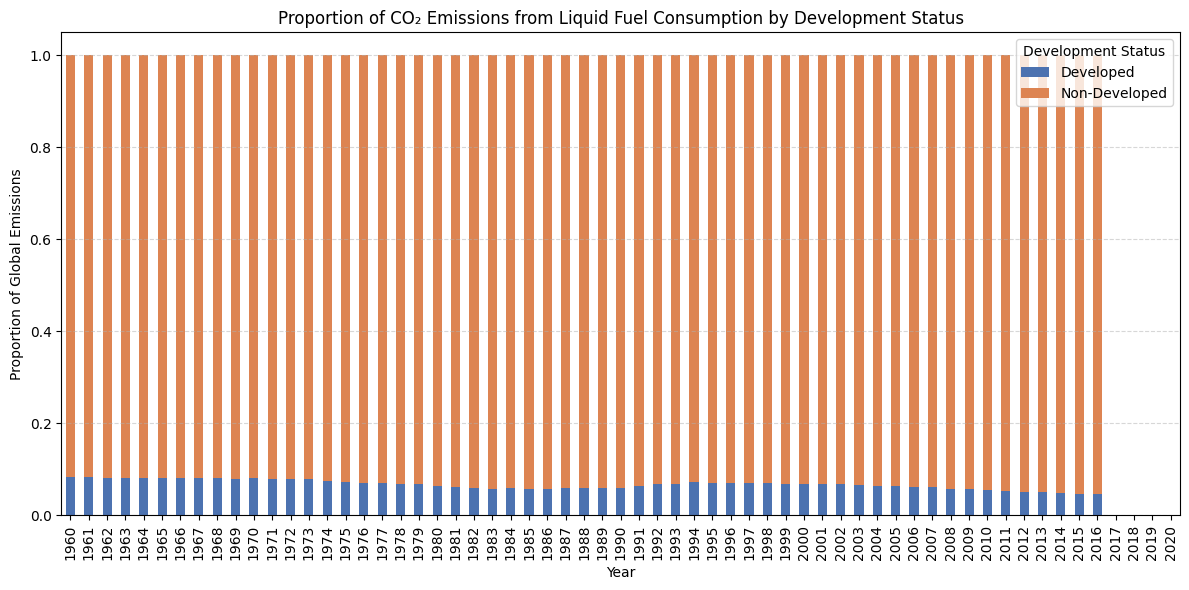

In [55]:
grouped = df.groupby(['Year', 'Development Status'])['average_value_CO2 emissions from liquid fuel consumption (kt)'].sum().unstack()

# Calculate proportions
proportions = grouped.div(grouped.sum(axis=1), axis=0)

# Plot as a stacked bar chart
proportions.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6),
    color=['#4c72b0', '#dd8452']  # Custom colors: Developed, Non-Developed
)

# Add labels and title
plt.title('Proportion of CO₂ Emissions from Liquid Fuel Consumption by Development Status')
plt.xlabel('Year')
plt.ylabel('Proportion of Global Emissions')
plt.legend(title='Development Status')
plt.tight_layout()
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.show()

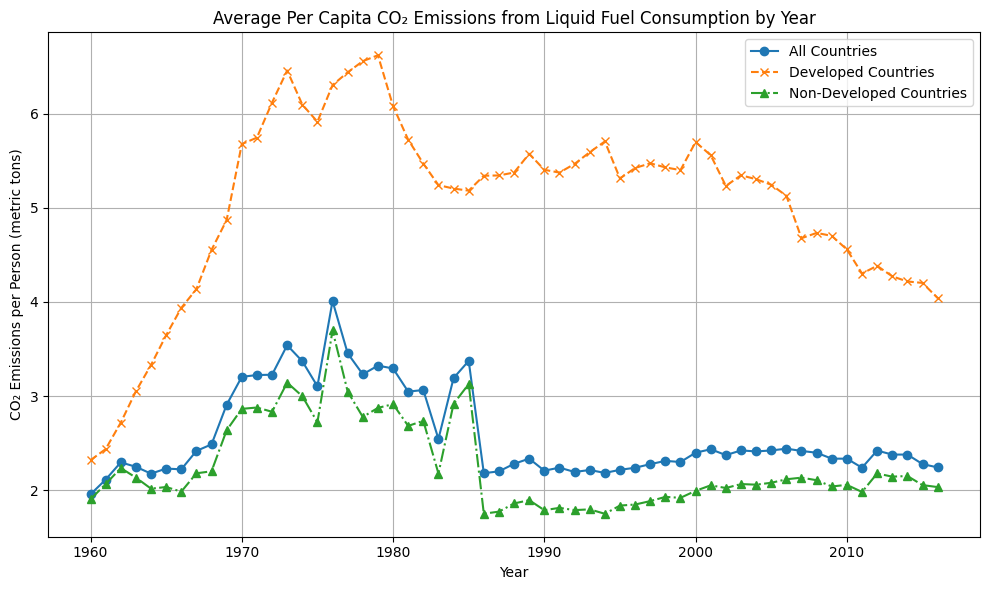

In [56]:
df['CO2 per capita'] = df['average_value_CO2 emissions from liquid fuel consumption (kt)'] * 1_000 / df['average_value_Population, total']

# Step 2: Group by year for each category
cf_all = df.groupby('Year')['CO2 per capita'].mean()
cf_developed = df[df['Development Status'] == 'Developed'].groupby('Year')['CO2 per capita'].mean()
cf_non_developed = df[df['Development Status'] == 'Non-Developed'].groupby('Year')['CO2 per capita'].mean()

# Step 3: Plotting
plt.figure(figsize=(10, 6))
cf_all.plot(kind='line', marker='o', label='All Countries')
cf_developed.plot(kind='line', marker='x', label='Developed Countries', linestyle='--')
cf_non_developed.plot(kind='line', marker='^', label='Non-Developed Countries', linestyle='-.')

# Step 4: Labels & title
plt.title('Average Per Capita CO₂ Emissions from Liquid Fuel Consumption by Year')
plt.xlabel('Year')
plt.ylabel('CO₂ Emissions per Person (metric tons)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

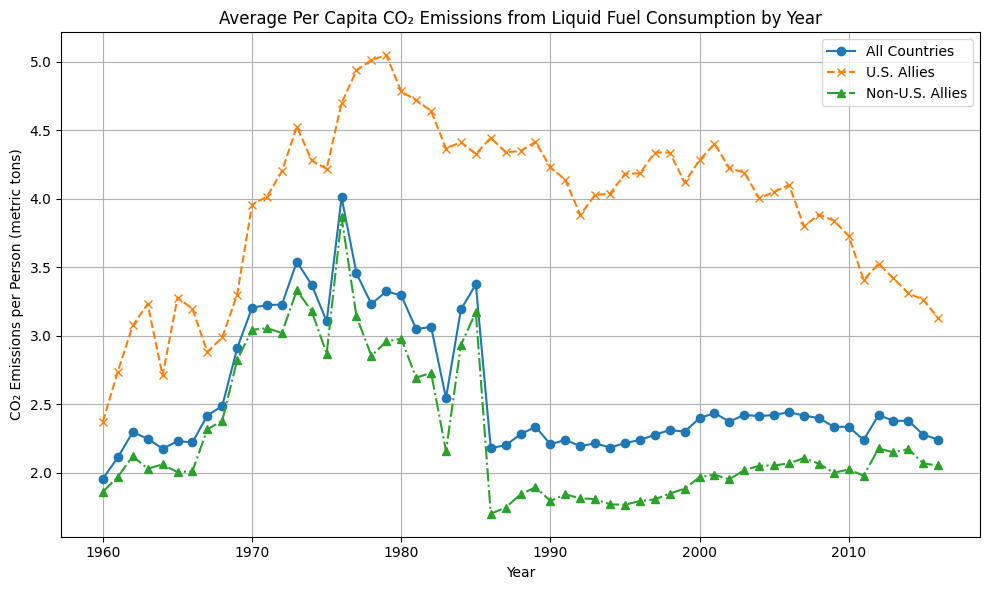

In [57]:
df['CO2 per capita'] = df['average_value_CO2 emissions from liquid fuel consumption (kt)'] * 1_000 / df['average_value_Population, total']

# Step 2: Group by Year and Ally status
cf_all = df.groupby('Year')['CO2 per capita'].mean()
cf_allies = df[df['USA ally']].groupby('Year')['CO2 per capita'].mean()
cf_non_allies = df[~df['USA ally']].groupby('Year')['CO2 per capita'].mean()

# Step 3: Plotting
plt.figure(figsize=(10, 6))
cf_all.plot(kind='line', marker='o', label='All Countries')
cf_allies.plot(kind='line', marker='x', label='U.S. Allies', linestyle='--')
cf_non_allies.plot(kind='line', marker='^', label='Non-U.S. Allies', linestyle='-.')

# Step 4: Labels & title
plt.title('Average Per Capita CO₂ Emissions from Liquid Fuel Consumption by Year')
plt.xlabel('Year')
plt.ylabel('CO₂ Emissions per Person (metric tons)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

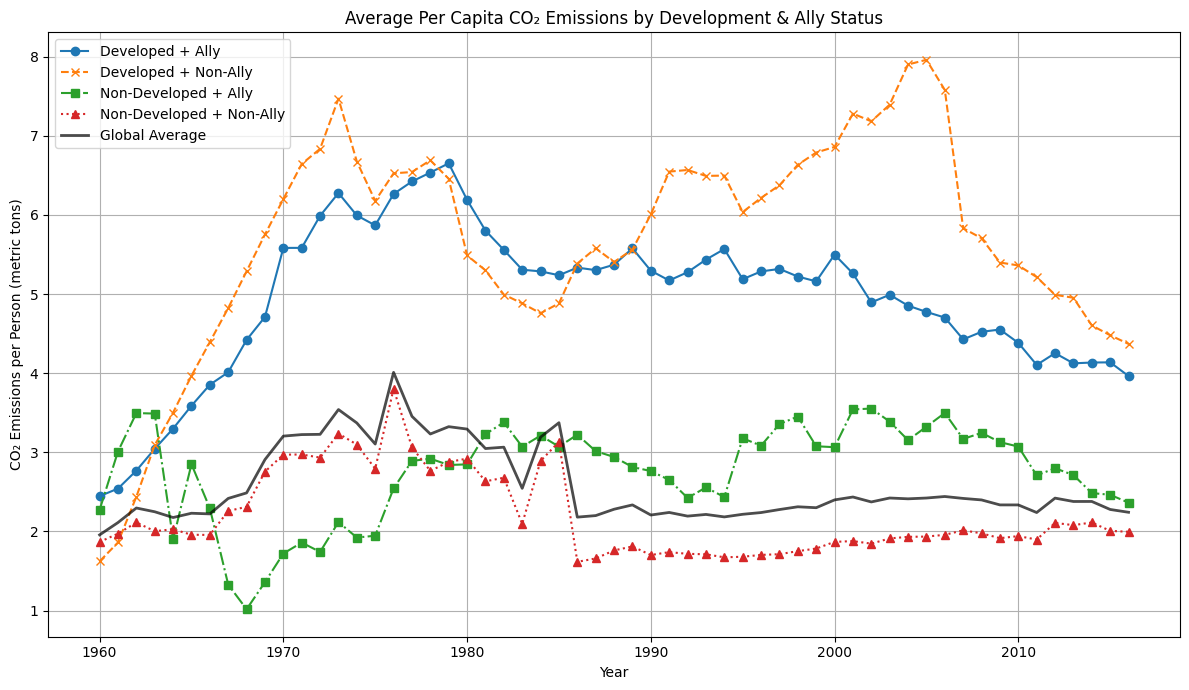

In [58]:
df['CO2 per capita'] = df['average_value_CO2 emissions from liquid fuel consumption (kt)'] * 1_000 / df['average_value_Population, total']

# Step 2: Define group filters
dev_ally = df[(df['Development Status'] == 'Developed') & (df['USA ally'])]
dev_nonally = df[(df['Development Status'] == 'Developed') & (~df['USA ally'])]
nondev_ally = df[(df['Development Status'] == 'Non-Developed') & (df['USA ally'])]
nondev_nonally = df[(df['Development Status'] == 'Non-Developed') & (~df['USA ally'])]

# Step 3: Grouped averages
cf_dev_ally = dev_ally.groupby('Year')['CO2 per capita'].mean()
cf_dev_nonally = dev_nonally.groupby('Year')['CO2 per capita'].mean()
cf_nondev_ally = nondev_ally.groupby('Year')['CO2 per capita'].mean()
cf_nondev_nonally = nondev_nonally.groupby('Year')['CO2 per capita'].mean()

# Step 4: Global average per capita
cf_global = df.groupby('Year')['CO2 per capita'].mean()

# Step 5: Plotting
plt.figure(figsize=(12, 7))
cf_dev_ally.plot(label='Developed + Ally', marker='o', linestyle='-')
cf_dev_nonally.plot(label='Developed + Non-Ally', marker='x', linestyle='--')
cf_nondev_ally.plot(label='Non-Developed + Ally', marker='s', linestyle='-.')
cf_nondev_nonally.plot(label='Non-Developed + Non-Ally', marker='^', linestyle=':')
cf_global.plot(label='Global Average', color='black', linewidth=2, linestyle='-', alpha=0.7)

# Step 6: Styling
plt.title('Average Per Capita CO₂ Emissions by Development & Ally Status')
plt.xlabel('Year')
plt.ylabel('CO₂ Emissions per Person (metric tons)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()